In [1]:
%matplotlib widget
import torch
import matplotlib.pyplot as plt
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.operations import sph_op
from diffSPH.kernels import getSPHKernelv2

from diffSPH.dataLoader import *
from BasisConvolution.convLayerv3 import BasisConvLayer

configuration = DataConfiguration(
    frameDistance=1,
    frameSpacing=1,
    maxRollout=1,
    historyLength=1,
    skipInitialFrames=0,
    cutoff=0
)
folder = './exampleData/'


processed = processFolder(folder, configuration)

for file in processed:
    print(f'File: {file["fileName"]}, FrameCount: {len(file["frames"])}, Samples: {len(file["samples"])}, Style: {file["style"]}, Number of samples: {len(processed[0]["samples"])}, first sample: {processed[0]["samples"][0]}, last sample: {processed[0]["samples"][-1]}')

dataset, datasetLoader = getDataLoader(processed, 4, shuffle = True)
datasetIter = iter(datasetLoader)

File: ./exampleData//wcsph_False_False_0_1024_2025-08-12_13-28-06_3094636111.h5, FrameCount: 1023, Samples: 1023, Style: diffSPH, Number of samples: 1023, first sample: 000001, last sample: 001023
File: ./exampleData//wcsph_False_True_0_1024_2025-08-12_13-28-06_3094636111.h5, FrameCount: 1023, Samples: 1023, Style: diffSPH, Number of samples: 1023, first sample: 000001, last sample: 001023
File: ./exampleData//wcsph_True_False_0_1024_2025-08-12_13-28-06_3094636111.h5, FrameCount: 1023, Samples: 1023, Style: diffSPH, Number of samples: 1023, first sample: 000001, last sample: 001023
File: ./exampleData//wcsph_True_True_0_1024_2025-08-12_13-28-06_3094636111.h5, FrameCount: 1023, Samples: 1023, Style: diffSPH, Number of samples: 1023, first sample: 000001, last sample: 001023


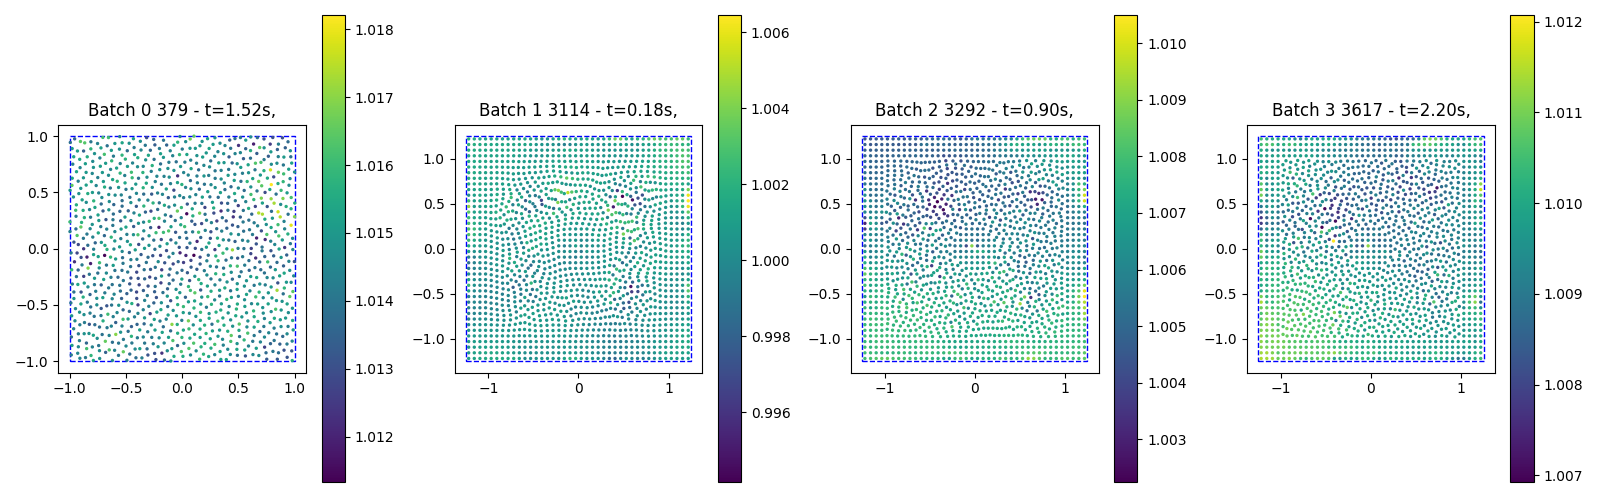

In [2]:
nextData = next(datasetIter)

priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
    dataset, nextData, configuration, device = 'cuda', dtype = torch.float32,
    augmentAngle = False,
)

fig, axis = plt.subplots(1, len(nextData), figsize=(len(nextData) * 4, 5), squeeze = False)
# filteredNeighborhood = filterNeighborhoodByKind(currentStates[0], neighborhoods[0], 'noghost')

plots = []
axes = axis.flatten()
for b in range(len(domains)):
    plot = visualizeParticles(fig, axes[b],
                              particles = currentState,
                              domain = domains[b],
                              quantity = currentState.densities,
                              which = 'both',
                              mapping = 'L2',
                              cmap = 'viridis',
                              visualizeBoth=True,
                              kernel = kernelNameToKernel(configs[b]['kernel']),
                              plotDomain = True,
                              gridVisualization=False, markerSize=2,
                              batch = b, streamLines = False)
    axes[b].set_title(f'Batch {b} {nextData[b]} - t={currentState.time[b]:.2f}s,')
    plots.append(plot)

fig.tight_layout()

In [3]:
def evalDensity(state, neighborhood, domains, config):
    quantity = torch.ones_like(state.densities)

    return sph_op(
        state, state, domains, getSPHKernelv2('Wendland2'), neighborhood, quantity = state.velocities, supportScheme='gather', operation = 'density'
    )

filteredNeighborhood = filterNeighborhoodByKind(currentState, neighborhoods, 'noghost')
filtered_csr = coo_to_csr(filteredNeighborhood)
print(f'Filtered neighborhood: {filtered_csr}')

rho = evalDensity(currentState, filteredNeighborhood, domains, configs[0])

for b in range(len(domains)):
    updatePlot(plots[b], particles = currentState, quantity = filtered_csr.rowEntries, mapping = 'L2', cmap = 'viridis')

Filtered neighborhood: SparseCSR(indices=tensor([ 814,   25,  211,  ..., 5974, 6012, 6013], device='cuda:0'), indptr=tensor([     0,     50,    102,  ..., 284770, 284770, 284770], device='cuda:0',
       dtype=torch.int32), rowEntries=tensor([50, 52, 52,  ...,  0,  0,  0], device='cuda:0'), numRows=[1024, 2228, 2228, 2228], numCols=[1024, 2228, 2228, 2228])


In [4]:
def buildNetwork(
        mode = 'conv',
        basis = 'linear',
        basisTerms = 4,
        layerCount = 2,
        layerWidth = 128,
        inputFeatures = 1,
        outputFeatures = 1,
        dim = 2
):
    testLayerGNN = BasisConvLayer(
    inputFeatures = inputFeatures,
    outputFeatures = outputFeatures,
    dim = dim,

    basisTerms = basisTerms,
    basisFunction = basis,
    basisPeriodicity = False,

    biasActive= False,
    cutlassBatchSize= 16,

    mode = mode, edgeSkip = 'none', mlpProperties = {
            'activation': 'celu',
            'gain': 1,
            'norm': False,
            'preNorm': False,
            'postNorm': False,
            'noLinear': False,
            'bias': False,
            'groups': [1],
            'layout': [layerWidth] * layerCount,
    }).to('cuda', dtype = torch.float32)

    return testLayerGNN

In [5]:

testLayerCConv = buildNetwork(mode = 'conv', basis = 'linear', basisTerms = 4)
testLayerGNN = buildNetwork(mode = 'mlp', layerCount = 2, layerWidth = 128)

numParametersCConv = sum(p.numel() for p in testLayerCConv.parameters() if p.requires_grad)
print(f'Number of parameters in the Conv layer: {numParametersCConv}')
numParametersGNN = sum(p.numel() for p in testLayerGNN.parameters() if p.requires_grad)
print(f'Number of parameters in the GNN layer: {numParametersGNN}')


Number of parameters in the Conv layer: 16
Number of parameters in the GNN layer: 17152


In [6]:
def trainLayer(testLayer, datasetLoader, iterations, initialLR):
    optimizer = torch.optim.Adam(testLayer.parameters(), lr=initialLR)

    losses = []
    datasetIter = iter(datasetLoader)
    
    for i in (tq := tqdm(range(iterations), leave = False)):
        try:
            batch = next(datasetIter)
        except StopIteration:
            datasetIter = iter(datasetLoader)
            batch = next(datasetIter)
        nextData = batch

        priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
            dataset, nextData, configuration, device = 'cuda', dtype = torch.float32,
            augmentAngle = True,
        )

        inputFeatures = torch.ones_like(currentState.densities).unsqueeze(-1)

        filteredNeighborhood = filterNeighborhoodByKind(currentState, neighborhoods, 'noghost')
        edge_index = torch.stack([filteredNeighborhood.row, filteredNeighborhood.col])

        rij, xij_, h_i, h_j = evalDistanceTensor(filteredNeighborhood)
        edge_attr = xij_ / h_i[:,None]



        optimizer.zero_grad()
        out, _ = testLayer(
            x = [inputFeatures, inputFeatures],
            edge_index = edge_index,
            edge_attr = edge_attr,
            batches = 1,
        )

        rho = evalDensity(currentState, filteredNeighborhood, domains, configs[0]) #/ configs[0]['fluid']['rho0']
        gt = rho
        gt = gt.reshape(-1, 1)

        error = gt - out
        error = error[currentState.kinds == 0]

        loss = torch.sum(error ** 2)
        loss.backward()

        optimizer.step()
        tq.set_description(f'Loss: {loss.item():.4f} [{nextData}], Density: {torch.mean(gt[currentState.kinds == 0]):.4f} +- {torch.std(gt[currentState.kinds == 0]):.4f}, Output: {torch.mean(out[currentState.kinds == 0]):.4f} +- {torch.std(out[currentState.kinds == 0]):.4f}, {[f'{t:.4f}' for t in currentState.time]}')
        losses.append(loss.item())
    return testLayer, losses

In [7]:
testLayerCConvTrained, losses = trainLayer(testLayerCConv, datasetLoader, iterations = 2000, initialLR = 1e-3)

  0%|          | 0/2000 [00:00<?, ?it/s]

In [8]:
testLayerGNNTrained, lossesGNN = trainLayer(testLayerGNN, datasetLoader, iterations = 2000, initialLR = 1e-3)

  0%|          | 0/2000 [00:00<?, ?it/s]

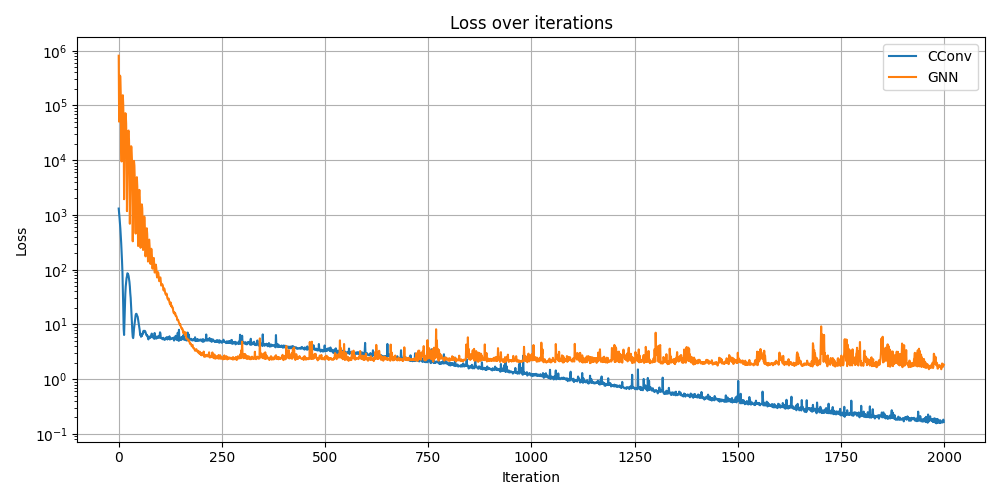

In [10]:
fig, axis = plt.subplots(1, 1, figsize=(10, 5), squeeze = False)

axis[0,0].plot(losses, label = 'CConv')
axis[0,0].plot(lossesGNN, label = 'GNN')
axis[0,0].set_title('Loss over iterations')
axis[0,0].set_xlabel('Iteration')
axis[0,0].set_ylabel('Loss')

axis[0,0].grid(True)
axis[0,0].set_yscale('log')
axis[0,0].legend()
fig.tight_layout()

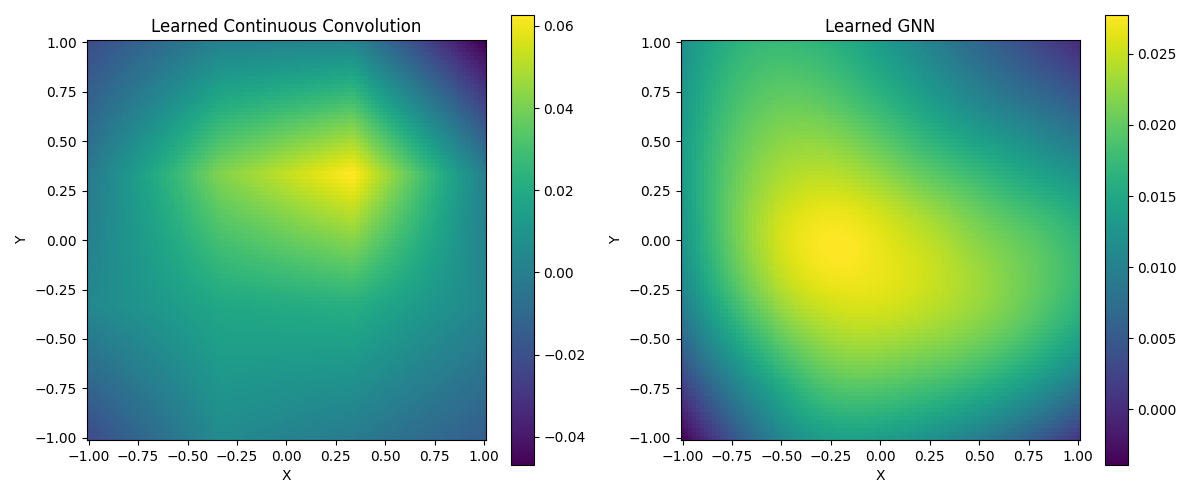

In [13]:
xx = torch.linspace(-1, 1, 101).to('cuda', dtype = torch.float32)
yy = torch.linspace(-1, 1, 101).to('cuda', dtype = torch.float32)
X, Y = torch.meshgrid(xx, yy, indexing='ij')
edge_attr = torch.stack([X.flatten(), Y.flatten()], dim=-1).to('cuda', dtype = torch.float32)

edge_index = torch.stack([torch.arange(X.numel()).to('cuda'), torch.zeros_like(X).flatten().to(torch.int64)])
inputs = torch.ones_like(X).flatten().unsqueeze(-1).to('cuda', dtype = torch.float32)

outCConv, _ = testLayerCConv(
    x = [inputs, inputs],
    edge_index = edge_index,
    edge_attr = edge_attr,
    batches = 1,
)
outGNN, _ = testLayerGNN(
    x = [inputs, inputs],
    edge_index = edge_index,
    edge_attr = edge_attr,
    batches = 1,
)

fig, axis = plt.subplots(1, 2, figsize=(12, 5), squeeze = False)

sc = axis[0,0].pcolormesh(X.cpu().numpy(), Y.cpu().numpy(), outCConv[:,0].detach().cpu().numpy().reshape(X.shape), shading='auto', cmap='viridis')
fig.colorbar(sc, ax=axis[0,0], orientation='vertical')
axis[0,0].set_title('Learned Continuous Convolution')

sc = axis[0,1].pcolormesh(X.cpu().numpy(), Y.cpu().numpy(), outGNN[:,0].detach().cpu().numpy().reshape(X.shape), shading='auto', cmap='viridis')
fig.colorbar(sc, ax=axis[0,1], orientation='vertical')
axis[0,1].set_title('Learned GNN')

for ax in axis.flatten():
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal')

fig.tight_layout()